In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
fastf1.Cache.enable_cache("../cache")

print("FastF1 cache enabled!")

FastF1 cache enabled!


In [3]:
session = fastf1.get_session(
    2026,
    "Australia",
    "Q"
)

session.load(
    telemetry=True,
    laps=True,
    weather=False,
    messages=False
)

print("Session loaded successfully!")

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	Using cached data for season_schedule
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached dat

Session loaded successfully!


In [4]:
driver1 = "RUS"
driver2 = "LEC"

print("Driver 1: George Russell")
print("Driver 2: Charles Leclerc")

Driver 1: George Russell
Driver 2: Charles Leclerc


In [5]:
driver1_laps = session.laps.pick_drivers(driver1)
driver2_laps = session.laps.pick_drivers(driver2)

fastest_lap_1 = driver1_laps.pick_fastest()
fastest_lap_2 = driver2_laps.pick_fastest()

print("George Russell fastest lap:", fastest_lap_1["LapNumber"])
print("Charles Leclerc fastest lap:", fastest_lap_2["LapNumber"])

George Russell fastest lap: 21.0
Charles Leclerc fastest lap: 23.0


In [6]:
telemetry_rus = fastest_lap_1.get_telemetry()
telemetry_lec = fastest_lap_2.get_telemetry()

print("Russell telemetry:", telemetry_rus.shape)
print("Leclerc telemetry:", telemetry_lec.shape)

Russell telemetry: (567, 18)
Leclerc telemetry: (578, 18)


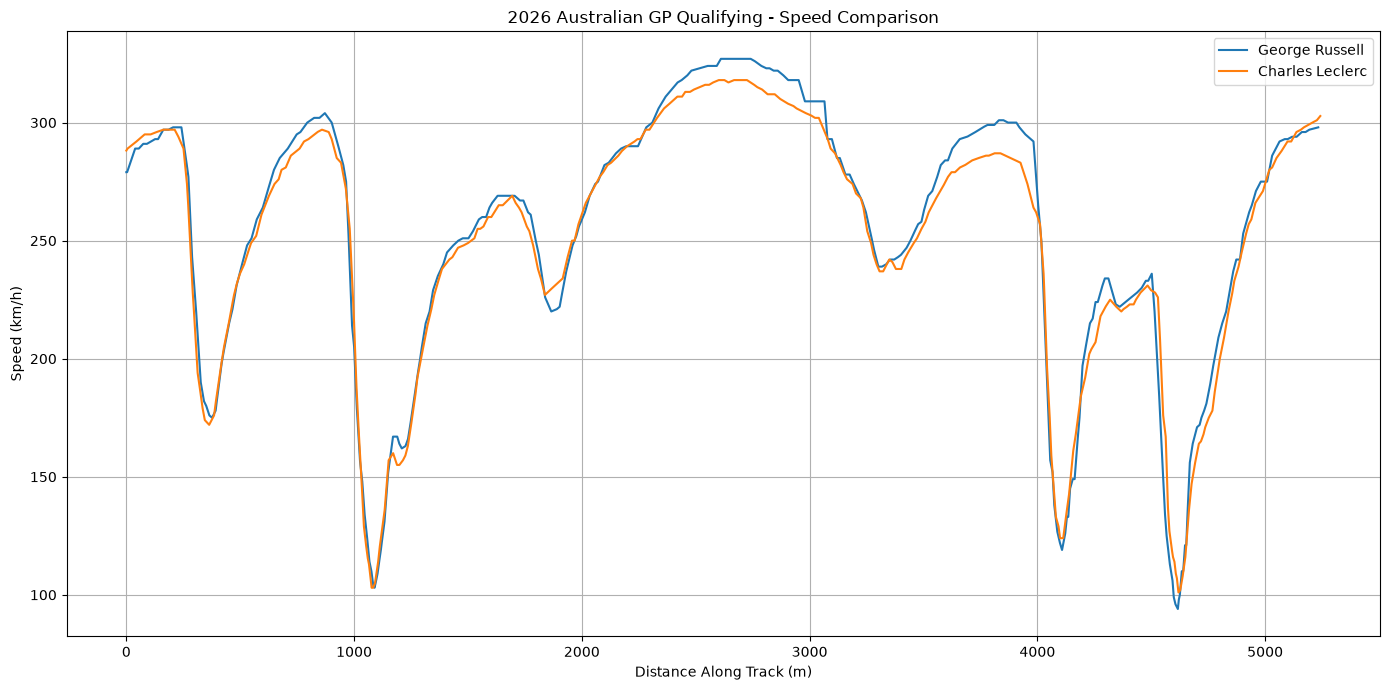

In [ ]:
# Speed vs Distance
plt.figure(figsize=(14, 7))

plt.plot(
    telemetry_rus["Distance"],
    telemetry_rus["Speed"],
    label="George Russell"
)

plt.plot(
    telemetry_lec["Distance"],
    telemetry_lec["Speed"],
    label="Charles Leclerc"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel("Speed (km/h)")

plt.title(
    "2026 Australian GP Qualifying - Speed Comparison"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [8]:
lap_time_rus = fastest_lap_1["LapTime"].total_seconds()
lap_time_lec = fastest_lap_2["LapTime"].total_seconds()

lap_difference = lap_time_rus - lap_time_lec

print(f"George Russell lap time: {lap_time_rus:.3f} seconds")
print(f"Charles Leclerc lap time: {lap_time_lec:.3f} seconds")
print(f"Lap time difference: {lap_difference:.3f} seconds")

George Russell lap time: 78.518 seconds
Charles Leclerc lap time: 79.327 seconds
Lap time difference: -0.809 seconds


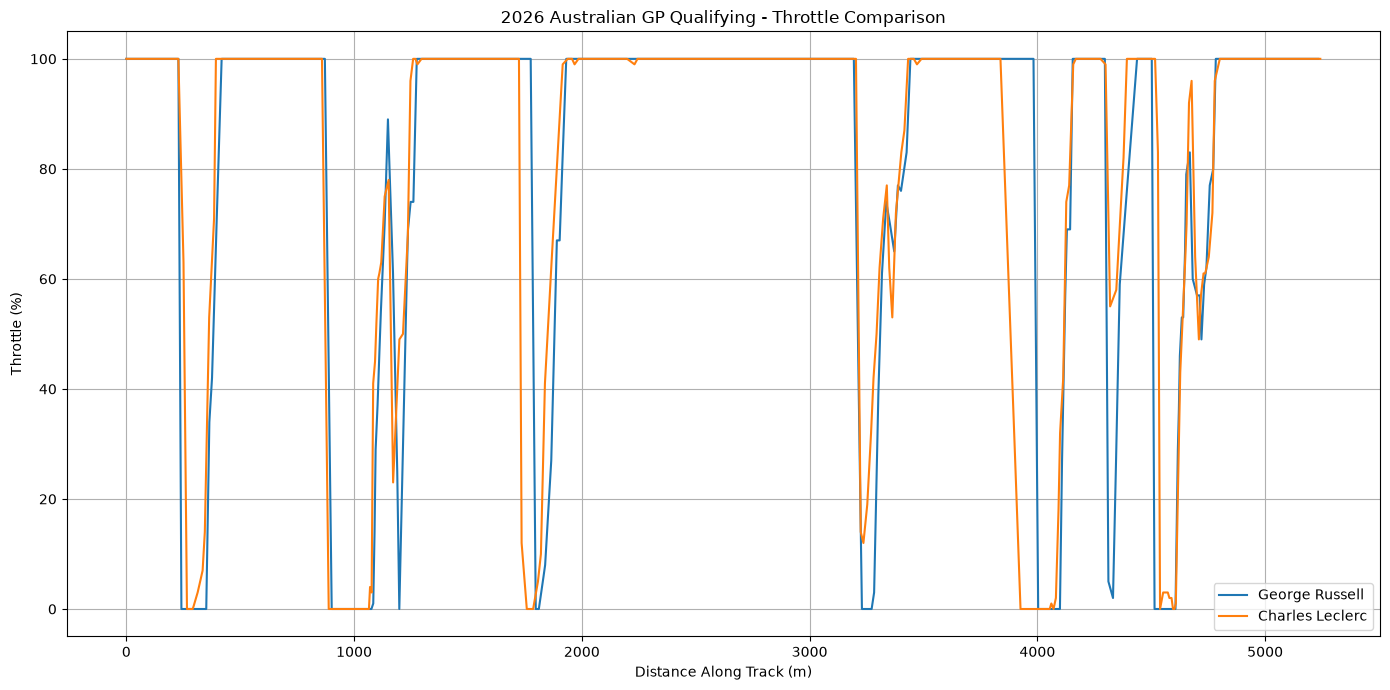

In [9]:
# ============================================================
# THROTTLE COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    telemetry_rus["Distance"],
    telemetry_rus["Throttle"],
    label="George Russell"
)

plt.plot(
    telemetry_lec["Distance"],
    telemetry_lec["Throttle"],
    label="Charles Leclerc"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel("Throttle (%)")

plt.title(
    "2026 Australian GP Qualifying - Throttle Comparison"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# THROTTLE STATISTICS
# ============================================================

rus_full_throttle = (
    telemetry_rus["Throttle"] >= 95
).mean() * 100

lec_full_throttle = (
    telemetry_lec["Throttle"] >= 95
).mean() * 100

rus_zero_throttle = (
    telemetry_rus["Throttle"] <= 5
).mean() * 100

lec_zero_throttle = (
    telemetry_lec["Throttle"] <= 5
).mean() * 100

print("========== THROTTLE STATISTICS ==========")

print(
    f"George Russell - >=95% throttle: "
    f"{rus_full_throttle:.2f}%"
)

print(
    f"Charles Leclerc - >=95% throttle: "
    f"{lec_full_throttle:.2f}%"
)

print(
    f"George Russell - <=5% throttle: "
    f"{rus_zero_throttle:.2f}%"
)

print(
    f"Charles Leclerc - <=5% throttle: "
    f"{lec_zero_throttle:.2f}%"
)

========== THROTTLE STATISTICS ==========
George Russell - >=95% throttle: 63.14%
Charles Leclerc - >=95% throttle: 64.36%
George Russell - <=5% throttle: 16.40%
Charles Leclerc - <=5% throttle: 13.84%


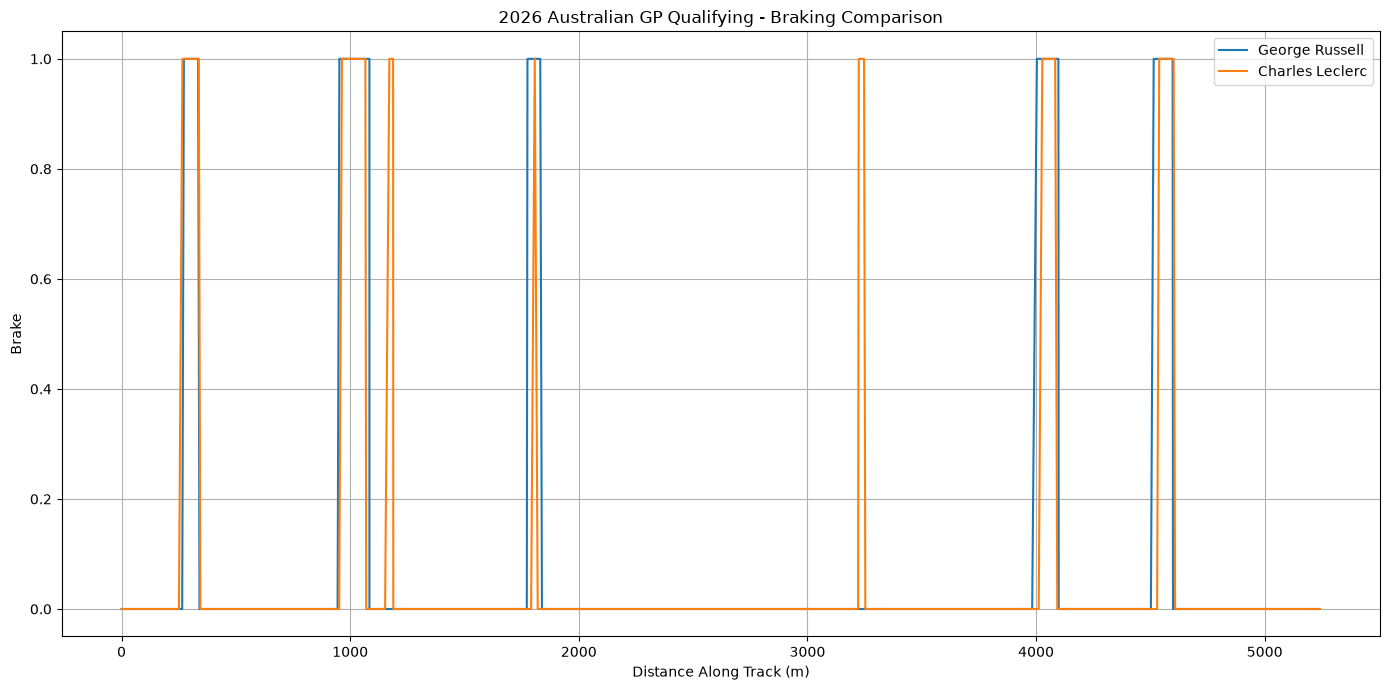

In [11]:
# ============================================================
# BRAKING COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    telemetry_rus["Distance"],
    telemetry_rus["Brake"],
    label="George Russell"
)

plt.plot(
    telemetry_lec["Distance"],
    telemetry_lec["Brake"],
    label="Charles Leclerc"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel("Brake")

plt.title(
    "2026 Australian GP Qualifying - Braking Comparison"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# BRAKING STATISTICS
# ============================================================

print("========== BRAKING STATISTICS ==========")

print(
    f"George Russell maximum brake: "
    f"{telemetry_rus['Brake'].max():.2f}"
)

print(
    f"Charles Leclerc maximum brake: "
    f"{telemetry_lec['Brake'].max():.2f}"
)

========== BRAKING STATISTICS ==========
George Russell maximum brake: 1.00
Charles Leclerc maximum brake: 1.00


In [13]:
# ============================================================
# IDENTIFY BRAKING ZONES
# ============================================================

def find_braking_zones(telemetry, driver_name):
    
    braking = telemetry[telemetry["Brake"] > 0].copy()
    
    if braking.empty:
        print(f"No braking data found for {driver_name}")
        return
    
    braking["DistanceDiff"] = braking["Distance"].diff()
    
    # Start a new braking zone when there is a large gap
    braking["Zone"] = (
        braking["DistanceDiff"] > 100
    ).cumsum()
    
    zones = braking.groupby("Zone").agg(
        Start_Distance=("Distance", "min"),
        End_Distance=("Distance", "max"),
        Max_Brake=("Brake", "max")
    ).reset_index(drop=True)
    
    zones["Braking_Distance"] = (
        zones["End_Distance"] -
        zones["Start_Distance"]
    )
    
    print(f"\n========== {driver_name.upper()} BRAKING ZONES ==========")
    print(zones)
    
    return zones


rus_braking_zones = find_braking_zones(
    telemetry_rus,
    "George Russell"
)

lec_braking_zones = find_braking_zones(
    telemetry_lec,
    "Charles Leclerc"
)


========== GEORGE RUSSELL BRAKING ZONES ==========
   Start_Distance  End_Distance  Max_Brake  Braking_Distance
0      272.613333    334.849902       True         62.236569
1      952.669444   1084.129206       True        131.459762
2     1775.413056   1831.375169       True         55.962114
3     4003.571111   4097.737830       True         94.166719
4     4514.505833   4597.213344       True         82.707511

========== CHARLES LECLERC BRAKING ZONES ==========
   Start_Distance  End_Distance  Max_Brake  Braking_Distance
0      266.257222    337.883317       True         71.626095
1      963.916667   1066.437931       True        102.521264
2     1171.339167   1187.702946       True         16.363779
3     1807.276944   1807.276944       True          0.000000
4     3224.504444   3247.582256       True         23.077812
5     4027.330556   4083.510746       True         56.180190
6     4538.618889   4601.807778       True         63.188889


In [15]:
# ============================================================
# COMMON DISTANCE GRID
# ============================================================

max_distance = min(
    telemetry_rus["Distance"].max(),
    telemetry_lec["Distance"].max()
)

distance_grid = np.linspace(
    0,
    max_distance,
    1000
)

print("Maximum common distance:", round(max_distance, 2), "m")
print("Comparison points:", len(distance_grid))

Maximum common distance: 5233.25 m
Comparison points: 1000


In [16]:
# ============================================================
# INTERPOLATE SPEED TO COMMON DISTANCES
# ============================================================

rus_speed = np.interp(
    distance_grid,
    telemetry_rus["Distance"],
    telemetry_rus["Speed"]
)

lec_speed = np.interp(
    distance_grid,
    telemetry_lec["Distance"],
    telemetry_lec["Speed"]
)

speed_difference = rus_speed - lec_speed

print("Speed comparison created successfully!")

Speed comparison created successfully!


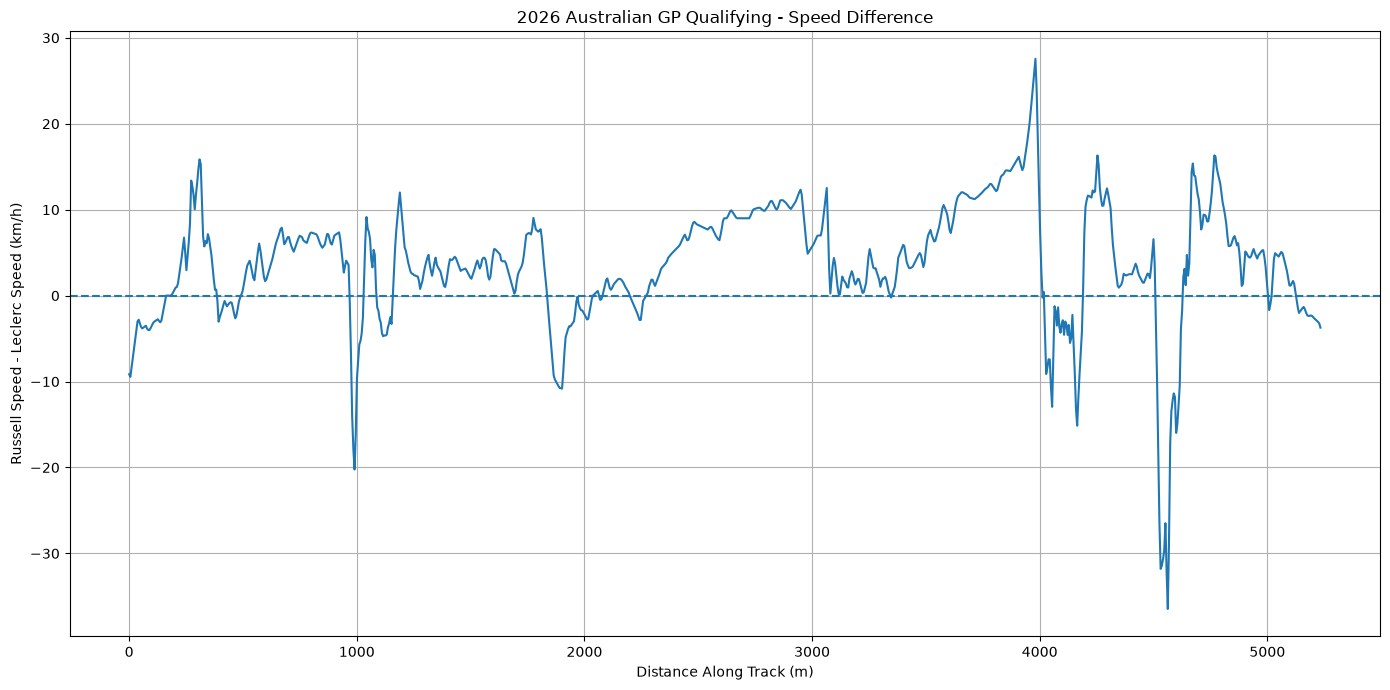

In [35]:
# ============================================================
# SPEED DIFFERENCE
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    distance_grid,
    speed_difference
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel("Russell Speed - Leclerc Speed (km/h)")

plt.title(
    "2026 Australian GP Qualifying - Speed Difference"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/speed_vs_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ============================================================
# LARGEST SPEED DIFFERENCES
# ============================================================

comparison = pd.DataFrame({
    "Distance": distance_grid,
    "RussellSpeed": rus_speed,
    "LeclercSpeed": lec_speed,
    "SpeedDifference": speed_difference
})

largest_russell_advantage = comparison.loc[
    comparison["SpeedDifference"].idxmax()
]

largest_leclerc_advantage = comparison.loc[
    comparison["SpeedDifference"].idxmin()
]

print("========== LARGEST SPEED DIFFERENCES ==========")

print("\nRussell's largest speed advantage:")
print(largest_russell_advantage)

print("\nLeclerc's largest speed advantage:")
print(largest_leclerc_advantage)

========== LARGEST SPEED DIFFERENCES ==========

Russell's largest speed advantage:
Distance           3981.249072
RussellSpeed        292.150896
LeclercSpeed        264.598400
SpeedDifference      27.552495
Name: 760, dtype: float64

Leclerc's largest speed advantage:
Distance           4562.720976
RussellSpeed        131.114848
LeclercSpeed        167.582145
SpeedDifference     -36.467297
Name: 871, dtype: float64


In [20]:
# ============================================================
# OVERALL SPEED COMPARISON
# ============================================================

average_russell_speed = comparison["RussellSpeed"].mean()
average_leclerc_speed = comparison["LeclercSpeed"].mean()

average_speed_difference = (
    average_russell_speed -
    average_leclerc_speed
)

print("========== OVERALL SPEED COMPARISON ==========")

print(
    f"Russell average speed: "
    f"{average_russell_speed:.2f} km/h"
)

print(
    f"Leclerc average speed: "
    f"{average_leclerc_speed:.2f} km/h"
)

print(
    f"Average speed difference "
    f"(Russell - Leclerc): "
    f"{average_speed_difference:.2f} km/h"
)

========== OVERALL SPEED COMPARISON ==========
Russell average speed: 256.19 km/h
Leclerc average speed: 252.42 km/h
Average speed difference (Russell - Leclerc): 3.76 km/h


In [21]:
# ============================================================
# SPEED ADVANTAGE DISTRIBUTION
# ============================================================

russell_faster = (
    comparison["SpeedDifference"] > 0
).mean() * 100

leclerc_faster = (
    comparison["SpeedDifference"] < 0
).mean() * 100

similar_speed = (
    comparison["SpeedDifference"].abs() < 1
).mean() * 100

print("========== SPEED ADVANTAGE DISTRIBUTION ==========")

print(
    f"Russell faster: "
    f"{russell_faster:.2f}% of comparison points"
)

print(
    f"Leclerc faster: "
    f"{leclerc_faster:.2f}% of comparison points"
)

print(
    f"Within ±1 km/h: "
    f"{similar_speed:.2f}% of comparison points"
)

========== SPEED ADVANTAGE DISTRIBUTION ==========
Russell faster: 78.40% of comparison points
Leclerc faster: 21.20% of comparison points
Within ±1 km/h: 7.90% of comparison points


In [22]:
# ============================================================
# DIVIDE LAP INTO THREE SECTIONS
# ============================================================

third = max_distance / 3

comparison["Section"] = pd.cut(
    comparison["Distance"],
    bins=[
        0,
        third,
        2 * third,
        max_distance
    ],
    labels=[
        "Section 1",
        "Section 2",
        "Section 3"
    ],
    include_lowest=True
)

print("========== SECTION DISTANCES ==========")

print(f"Section 1: 0 - {third:.2f} m")
print(f"Section 2: {third:.2f} - {2 * third:.2f} m")
print(f"Section 3: {2 * third:.2f} - {max_distance:.2f} m")

========== SECTION DISTANCES ==========
Section 1: 0 - 1744.42 m
Section 2: 1744.42 - 3488.83 m
Section 3: 3488.83 - 5233.25 m


In [23]:
# ============================================================
# SECTION-BY-SECTION SPEED COMPARISON
# ============================================================

section_speed = comparison.groupby(
    "Section",
    observed=True
)[
    ["RussellSpeed", "LeclercSpeed", "SpeedDifference"]
].mean()

print("\n========== SECTION SPEED COMPARISON ==========")

print(section_speed)


========== SECTION SPEED COMPARISON ==========
           RussellSpeed  LeclercSpeed  SpeedDifference
Section                                               
Section 1    243.394431    240.769261         2.625170
Section 2    287.415131    283.355487         4.059644
Section 3    237.789554    233.177005         4.612549


In [24]:
# ============================================================
# THROTTLE COMPARISON BY SECTION
# ============================================================

# Interpolate throttle to the common distance grid

rus_throttle = np.interp(
    distance_grid,
    telemetry_rus["Distance"],
    telemetry_rus["Throttle"]
)

lec_throttle = np.interp(
    distance_grid,
    telemetry_lec["Distance"],
    telemetry_lec["Throttle"]
)

comparison["RussellThrottle"] = rus_throttle
comparison["LeclercThrottle"] = lec_throttle

comparison["ThrottleDifference"] = (
    comparison["RussellThrottle"]
    - comparison["LeclercThrottle"]
)

# Calculate section averages

section_throttle = comparison.groupby(
    "Section",
    observed=True
)[
    [
        "RussellThrottle",
        "LeclercThrottle",
        "ThrottleDifference"
    ]
].mean()

print("========== SECTION THROTTLE COMPARISON ==========")

print(section_throttle)

========== SECTION THROTTLE COMPARISON ==========
           RussellThrottle  LeclercThrottle  ThrottleDifference
Section                                                        
Section 1        75.253481        76.714211           -1.460731
Section 2        87.391414        88.136378           -0.744964
Section 3        79.368163        77.014169            2.353994


In [25]:
# ============================================================
# BRAKING COMPARISON BY SECTION
# ============================================================

# Convert Brake from True/False to 1/0

rus_brake = np.interp(
    distance_grid,
    telemetry_rus["Distance"],
    telemetry_rus["Brake"].astype(float)
)

lec_brake = np.interp(
    distance_grid,
    telemetry_lec["Distance"],
    telemetry_lec["Brake"].astype(float)
)

comparison["RussellBrake"] = rus_brake
comparison["LeclercBrake"] = lec_brake

comparison["BrakeDifference"] = (
    comparison["RussellBrake"]
    - comparison["LeclercBrake"]
)

# Average brake signal by section

section_braking = comparison.groupby(
    "Section",
    observed=True
)[
    [
        "RussellBrake",
        "LeclercBrake",
        "BrakeDifference"
    ]
].mean()

print("========== SECTION BRAKING COMPARISON ==========")

print(section_braking)

print("\n========== BRAKING PERCENTAGE BY SECTION ==========")

print(
    section_braking[
        ["RussellBrake", "LeclercBrake"]
    ] * 100
)

========== SECTION BRAKING COMPARISON ==========
           RussellBrake  LeclercBrake  BrakeDifference
Section                                               
Section 1      0.115731      0.124089        -0.008358
Section 2      0.035233      0.023464         0.011768
Section 3      0.111407      0.079931         0.031476

========== BRAKING PERCENTAGE BY SECTION ==========
           RussellBrake  LeclercBrake
Section                              
Section 1     11.573075     12.408867
Section 2      3.523251      2.346432
Section 3     11.140728      7.993133


In [26]:
# ============================================================
# COMBINED SECTION ANALYSIS
# ============================================================

combined_section_analysis = pd.DataFrame({
    "Russell_Speed": comparison.groupby(
        "Section",
        observed=True
    )["RussellSpeed"].mean(),

    "Leclerc_Speed": comparison.groupby(
        "Section",
        observed=True
    )["LeclercSpeed"].mean(),

    "Speed_Difference": comparison.groupby(
        "Section",
        observed=True
    )["SpeedDifference"].mean(),

    "Russell_Throttle": comparison.groupby(
        "Section",
        observed=True
    )["RussellThrottle"].mean(),

    "Leclerc_Throttle": comparison.groupby(
        "Section",
        observed=True
    )["LeclercThrottle"].mean(),

    "Russell_Brake": comparison.groupby(
        "Section",
        observed=True
    )["RussellBrake"].mean() * 100,

    "Leclerc_Brake": comparison.groupby(
        "Section",
        observed=True
    )["LeclercBrake"].mean() * 100
})

print("========== COMBINED SECTION ANALYSIS ==========")

print(
    combined_section_analysis.round(2)
)

========== COMBINED SECTION ANALYSIS ==========
           Russell_Speed  Leclerc_Speed  Speed_Difference  Russell_Throttle  \
Section                                                                       
Section 1         243.39         240.77              2.63             75.25   
Section 2         287.42         283.36              4.06             87.39   
Section 3         237.79         233.18              4.61             79.37   

           Leclerc_Throttle  Russell_Brake  Leclerc_Brake  
Section                                                    
Section 1             76.71          11.57          12.41  
Section 2             88.14           3.52           2.35  
Section 3             77.01          11.14           7.99  


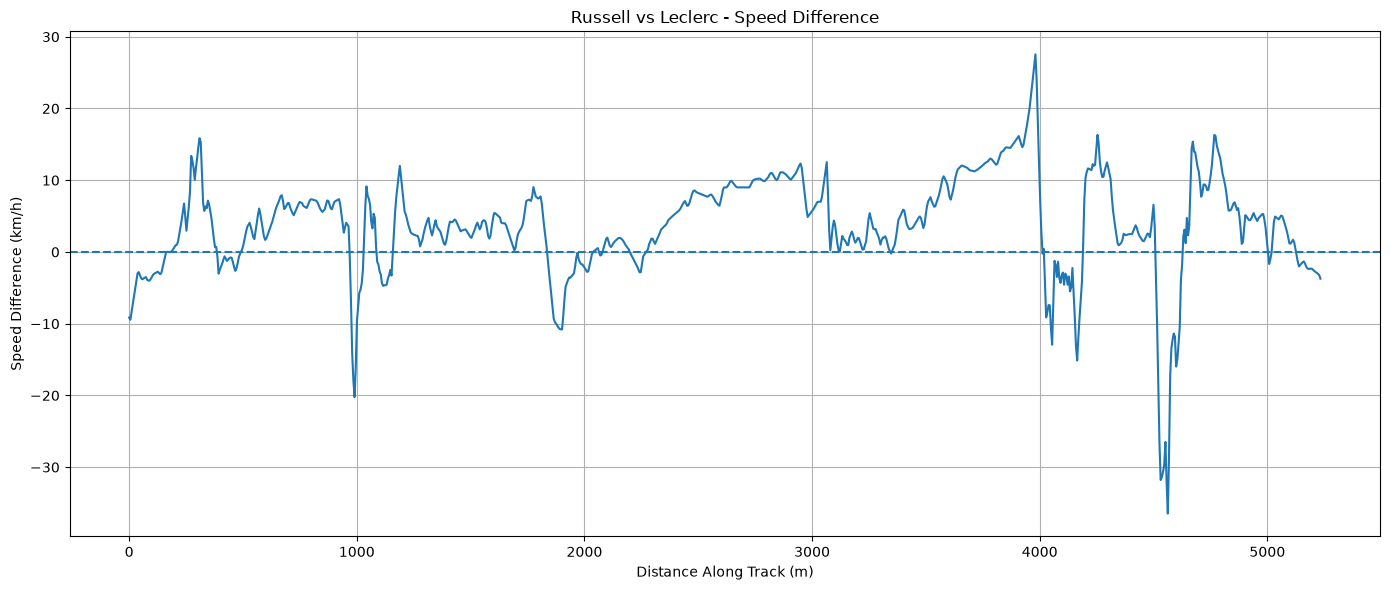

In [34]:
# ============================================================
# SPEED DIFFERENCE BY DISTANCE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Distance"],
    comparison["SpeedDifference"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel("Speed Difference (km/h)")

plt.title(
    "Russell vs Leclerc - Speed Difference"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/speed_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

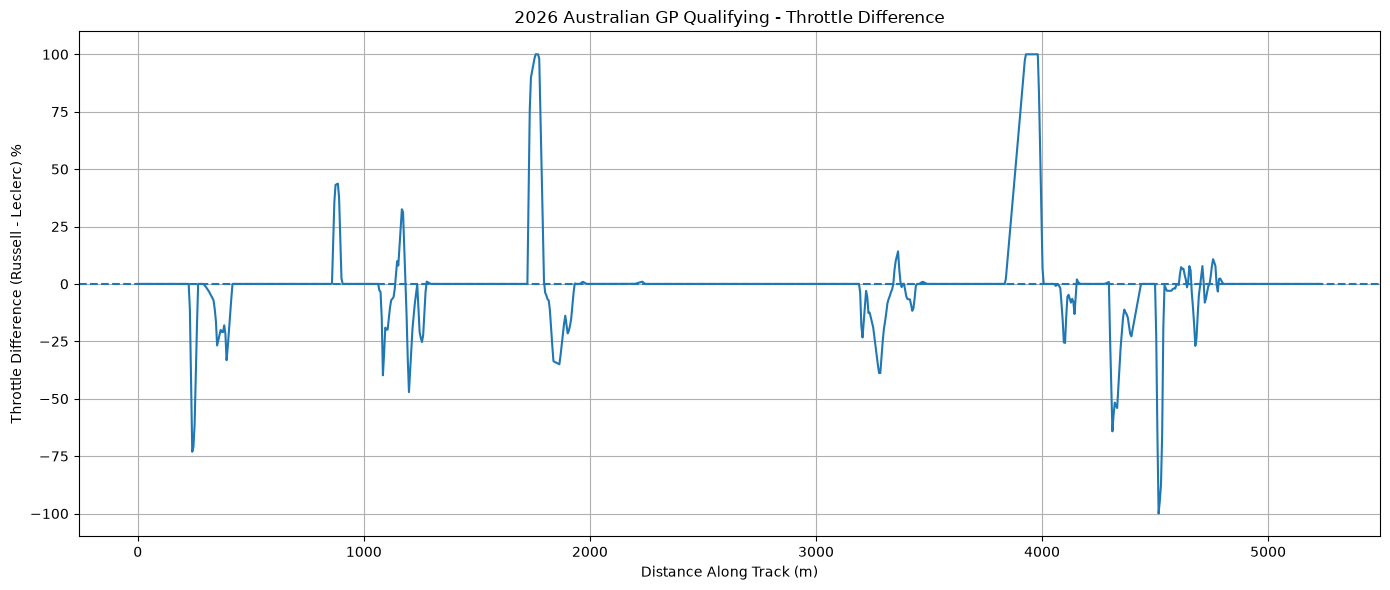

In [32]:
# ============================================================
# THROTTLE DIFFERENCE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Distance"],
    comparison["ThrottleDifference"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel(
    "Throttle Difference "
    "(Russell - Leclerc) %"
)

plt.title(
    "2026 Australian GP Qualifying - "
    "Throttle Difference"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/throttle_vs_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

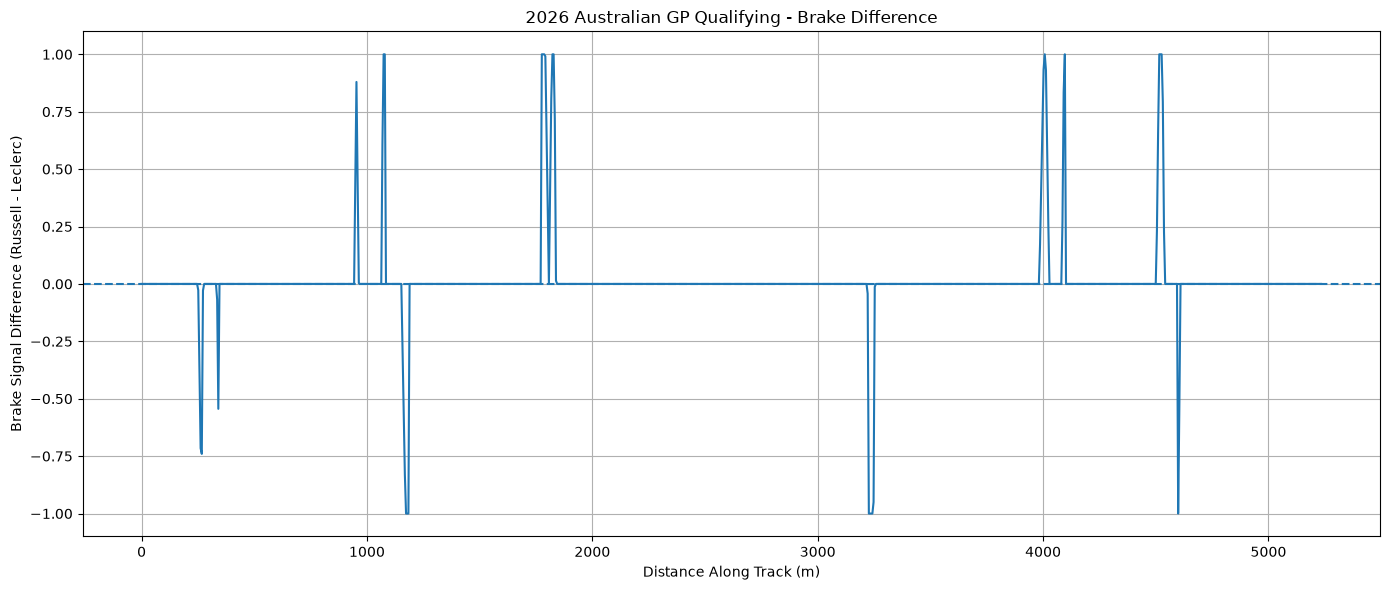

In [33]:
# ============================================================
# BRAKE DIFFERENCE
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Distance"],
    comparison["BrakeDifference"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Distance Along Track (m)")
plt.ylabel(
    "Brake Signal Difference "
    "(Russell - Leclerc)"
)

plt.title(
    "2026 Australian GP Qualifying - "
    "Brake Difference"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/brake_vs_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()